# 04h — E3c FaceForensics++ Internal Evaluation

**Experiment:** E3c — EfficientNet-B0 trained with official SBI and SAM with an SGD base optimiser  
**Purpose:** Evaluate the saved E3c checkpoint on the same genuine held-out FF++ real and manipulated face crops used for E3b, at frame and source-video level.

This notebook performs evaluation only. It does not generate SBI samples, train, adapt, select a checkpoint or tune the threshold.


## Evaluation protocol

- Use the identical clean FF++ test set used for E3b: 591 available precomputed 15%-margin face crops from 60 source videos.
- Match E3b/E3c tensor preprocessing: resize to 224×224 and scale to `[0,1]`; apply **no ImageNet mean/std normalisation**.
- Change only the loaded checkpoint from E3b Adam to E3c SAM-with-SGD.
- Respect the checkpoint orientation: model output 0 = real and output 1 = fake.
- Use the fixed 0.5 threshold without test-set optimisation.
- Report frame-level and video-level metrics separately; aggregate each video using mean fake probability.
- Do not generate SBI samples, retrain, adapt or select a checkpoint using this test set.


## 1. Evaluation control


In [1]:
RUN_EVALUATION = True

DECISION_THRESHOLD = 0.5
BATCH_SIZE = 16
NUM_WORKERS = 0

assert DECISION_THRESHOLD == 0.5
print("E3c evaluation enabled:", RUN_EVALUATION)


E3c evaluation enabled: True


## 2. Imports, paths and device


In [2]:
from google.colab import drive
drive.mount("/content/drive")

import os
import json
import cv2
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torchvision.models import efficientnet_b0
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve,
)

BASE_PATH = "/content/drive/MyDrive/deepfake_project"
TEST_DIR = os.path.join(BASE_PATH, "face_dataset", "test")
SPLIT_MANIFEST_PATH = os.path.join(BASE_PATH, "ffpp_video_split_manifest.json")
CHECKPOINT_PATH = os.path.join(BASE_PATH, "saved_models", "efficientnet_b0_official_sbi_sam_best.pth")
RESULTS_PATH = os.path.join(BASE_PATH, "results", "e3c_ffpp_evaluation.json")
CONFUSION_PLOT_PATH = os.path.join(BASE_PATH, "plots", "e3c_ffpp_confusion_matrix.png")
ROC_PLOT_PATH = os.path.join(BASE_PATH, "plots", "e3c_ffpp_roc_curve.png")
VIDEO_CONFUSION_PLOT_PATH = os.path.join(BASE_PATH, "plots", "e3c_ffpp_video_confusion_matrix.png")
VIDEO_ROC_PLOT_PATH = os.path.join(BASE_PATH, "plots", "e3c_ffpp_video_roc_curve.png")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("Test data:", TEST_DIR)
print("Checkpoint:", CHECKPOINT_PATH)
print("Split manifest:", SPLIT_MANIFEST_PATH)


Mounted at /content/drive
Device: cuda
Test data: /content/drive/MyDrive/deepfake_project/face_dataset/test
Checkpoint: /content/drive/MyDrive/deepfake_project/saved_models/efficientnet_b0_official_sbi_sam_best.pth
Split manifest: /content/drive/MyDrive/deepfake_project/ffpp_video_split_manifest.json


## 3. Validate E3c preprocessing and the clean genuine FF++ face-crop test split


In [3]:
IMAGE_SIZE = 224
REAL_INDEX = 0
FAKE_INDEX = 1

def image_to_tensor(image):
    image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_LINEAR)
    image = image.astype(np.float32) / 255.0
    image = image.transpose(2, 0, 1)
    return torch.tensor(image, dtype=torch.float32)

class GenuineFFPPFaceDataset(Dataset):
    def __init__(self, root_path):
        self.samples = []
        for class_name, label in (("real", REAL_INDEX), ("fake", FAKE_INDEX)):
            class_dir = os.path.join(root_path, class_name)
            if not os.path.isdir(class_dir):
                raise FileNotFoundError(class_dir)
            for file_name in sorted(os.listdir(class_dir)):
                if not file_name.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
                    continue
                stem = os.path.splitext(file_name)[0]
                if "_frame_" not in stem:
                    raise ValueError(f"Cannot recover source-video id from: {file_name}")
                self.samples.append({
                    "path": os.path.join(class_dir, file_name),
                    "label": label,
                    "class_name": class_name,
                    "video_id": stem.rsplit("_frame_", 1)[0],
                })
        if not self.samples:
            raise RuntimeError("No genuine FF++ face crops were found.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]
        image_bgr = cv2.imread(sample["path"])
        if image_bgr is None:
            raise RuntimeError(f"Could not read: {sample['path']}")
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        return image_to_tensor(image_rgb), sample["label"]

assert os.path.isfile(SPLIT_MANIFEST_PATH), f"Split manifest not found: {SPLIT_MANIFEST_PATH}"
test_dataset = GenuineFFPPFaceDataset(TEST_DIR)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
)

class_counts = {
    "real": sum(sample["label"] == REAL_INDEX for sample in test_dataset.samples),
    "fake": sum(sample["label"] == FAKE_INDEX for sample in test_dataset.samples),
}
if class_counts != {"real": 292, "fake": 299}:
    raise RuntimeError(f"Unexpected test class counts: {class_counts}")

with open(SPLIT_MANIFEST_PATH, "r", encoding="utf-8") as handle:
    split_manifest = json.load(handle)

ordered_frame_video_ids = [sample["video_id"] for sample in test_dataset.samples]
actual_test_video_ids = set(ordered_frame_video_ids)
expected_test_video_ids = {
    os.path.splitext(video_name)[0]
    for class_splits in split_manifest["classes"].values()
    for video_name in class_splits["test"]
}
if actual_test_video_ids != expected_test_video_ids:
    raise RuntimeError("E3c test crops do not match the saved video split manifest.")

for class_name, class_splits in split_manifest["classes"].items():
    split_ids = {split: {os.path.splitext(name)[0] for name in names} for split, names in class_splits.items()}
    if split_ids["train"] & split_ids["val"] or split_ids["train"] & split_ids["test"] or split_ids["val"] & split_ids["test"]:
        raise RuntimeError(f"Source-video overlap detected for class {class_name}")

print("Canonical label mapping: {'real': 0, 'fake': 1}")
print("Class counts:", class_counts)
print("Images:", len(test_dataset))
print("Source videos:", len(actual_test_video_ids))
print("PASS: genuine test data matches the clean video-level manifest.")
print("Real output index:", REAL_INDEX)
print("Fake output index:", FAKE_INDEX)


Canonical label mapping: {'real': 0, 'fake': 1}
Class counts: {'real': 292, 'fake': 299}
Images: 591
Source videos: 60
PASS: genuine test data matches the clean video-level manifest.
Real output index: 0
Fake output index: 1


## 4. Rebuild EfficientNet-B0 and strictly load the official E3c checkpoint


In [4]:
assert os.path.isfile(CHECKPOINT_PATH), f"E3c checkpoint not found: {CHECKPOINT_PATH}"

model = efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
state_dict = checkpoint.get("model_state_dict", checkpoint) if isinstance(checkpoint, dict) else checkpoint
state_dict = {key.removeprefix("module."): value for key, value in state_dict.items()}
model.load_state_dict(state_dict, strict=True)
if isinstance(checkpoint, dict):
    if checkpoint.get("experiment") not in (None, "E3c"):
        raise RuntimeError(f"Unexpected checkpoint experiment: {checkpoint.get('experiment')}")
    if checkpoint.get("classes") not in (None, ["real", "fake"]):
        raise RuntimeError(f"Unexpected checkpoint class order: {checkpoint.get('classes')}")
if isinstance(checkpoint, dict) and checkpoint.get("classes") not in (None, ["real", "fake"]):
    raise RuntimeError(f"Unexpected checkpoint class order: {checkpoint.get('classes')}")
model = model.to(DEVICE)
model.eval()

print("E3c checkpoint loaded successfully.")
if isinstance(checkpoint, dict):
    print("Checkpoint epoch:", checkpoint.get("epoch"))
    print("Synthetic validation accuracy:", checkpoint.get("best_val_accuracy"))
    print("Synthetic validation ROC-AUC:", checkpoint.get("best_val_auc"))
    print("Optimizer:", checkpoint.get("optimizer"))


E3c checkpoint loaded successfully.
Checkpoint epoch: 10
Synthetic validation accuracy: 91.89655172413794
Synthetic validation ROC-AUC: 0.9736741973840666
Optimizer: SAM with SGD


## 5. Run frame-level inference and retain source-video identities


In [5]:
if RUN_EVALUATION:
    all_labels = []
    all_predictions = []
    all_fake_probabilities = []
    all_video_ids = []
    frame_offset = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            logits = model(images)
            probabilities = torch.softmax(logits, dim=1)

            fake_probabilities = probabilities[:, FAKE_INDEX]
            predictions = torch.where(
                fake_probabilities >= DECISION_THRESHOLD,
                torch.full_like(fake_probabilities, FAKE_INDEX, dtype=torch.long),
                torch.full_like(fake_probabilities, REAL_INDEX, dtype=torch.long),
            )

            batch_size_actual = labels.size(0)
            all_video_ids.extend(
                ordered_frame_video_ids[
                    frame_offset:frame_offset + batch_size_actual
                ]
            )
            frame_offset += batch_size_actual

            all_labels.extend(labels.numpy().tolist())
            all_predictions.extend(predictions.cpu().numpy().tolist())
            all_fake_probabilities.extend(
                fake_probabilities.cpu().numpy().tolist()
            )

    if frame_offset != len(test_dataset):
        raise RuntimeError(
            f"Inference covered {frame_offset} frames, expected {len(test_dataset)}."
        )
    print("Frames evaluated:", len(all_labels))
else:
    print("Evaluation skipped safely.")
    print("Set RUN_EVALUATION = True to evaluate the existing E3c checkpoint.")

Frames evaluated: 591


## 6. Calculate, display and save frame/video metrics


E3c — FACEFORENSICS++ FRAME-LEVEL RESULTS
Frames evaluated : 591
Accuracy         : 59.39%
Macro precision  : 71.69%
Macro recall     : 59.83%
Macro F1-score   : 53.20%
Fake recall      : 22.74%
ROC-AUC          : 0.7097

              precision    recall  f1-score   support

        real     0.5506    0.9692    0.7022       292
        fake     0.8831    0.2274    0.3617       299

    accuracy                         0.5939       591
   macro avg     0.7169    0.5983    0.5320       591
weighted avg     0.7188    0.5939    0.5300       591

Confusion matrix [real, fake]:
[[283   9]
 [231  68]]

E3c — FACEFORENSICS++ VIDEO-LEVEL RESULTS
Videos evaluated : 60
Accuracy         : 61.67%
Macro precision  : 78.30%
Macro recall     : 61.67%
Macro F1-score   : 55.06%
Fake recall      : 23.33%
ROC-AUC          : 0.7911

              precision    recall  f1-score   support

        real     0.5660    1.0000    0.7229        30
        fake     1.0000    0.2333    0.3784        30

    accurac

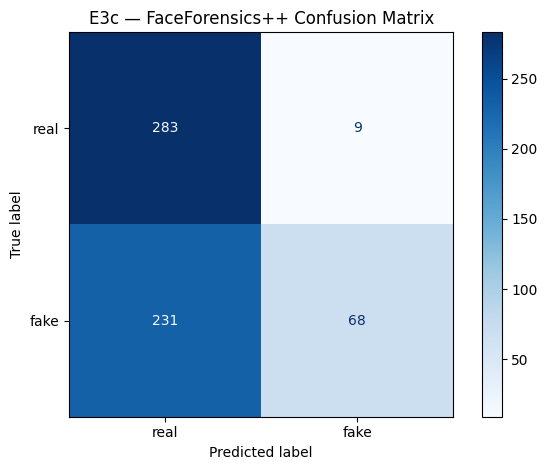

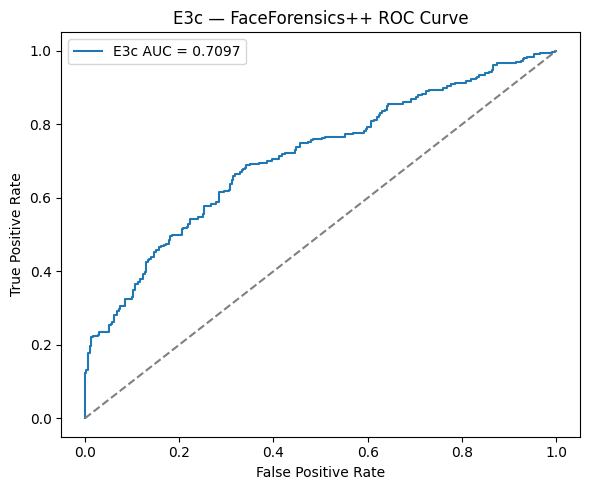

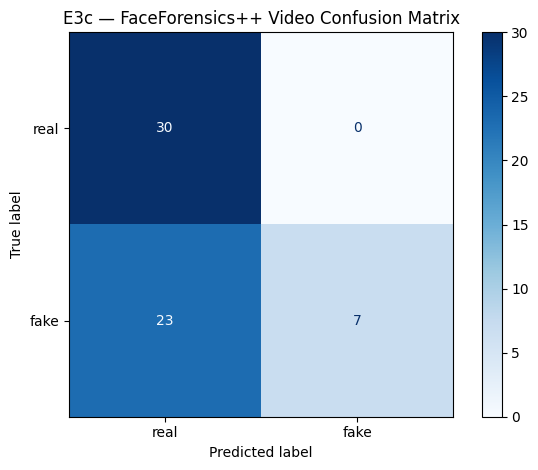

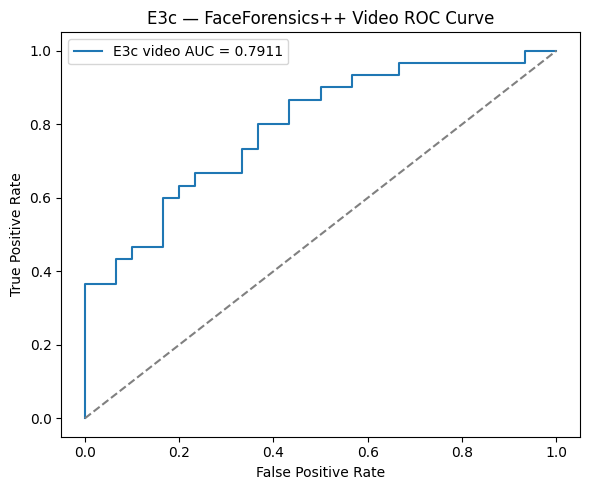

Results saved to: /content/drive/MyDrive/deepfake_project/results/e3c_ffpp_evaluation.json
Confusion matrix saved to: /content/drive/MyDrive/deepfake_project/plots/e3c_ffpp_confusion_matrix.png
ROC curve saved to: /content/drive/MyDrive/deepfake_project/plots/e3c_ffpp_roc_curve.png
Video confusion matrix saved to: /content/drive/MyDrive/deepfake_project/plots/e3c_ffpp_video_confusion_matrix.png
Video ROC curve saved to: /content/drive/MyDrive/deepfake_project/plots/e3c_ffpp_video_roc_curve.png


In [6]:
if RUN_EVALUATION:
    binary_fake_labels = (
        np.asarray(all_labels) == FAKE_INDEX
    ).astype(int)

    accuracy = accuracy_score(all_labels, all_predictions)
    macro_precision = precision_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0,
    )
    macro_recall = recall_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0,
    )
    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0,
    )
    fake_recall = recall_score(
        all_labels,
        all_predictions,
        labels=[FAKE_INDEX],
        average="macro",
        zero_division=0,
    )
    roc_auc = roc_auc_score(
        binary_fake_labels,
        all_fake_probabilities,
    )

    video_records = {}
    for video_id, label, fake_probability in zip(
        all_video_ids,
        all_labels,
        all_fake_probabilities,
    ):
        record = video_records.setdefault(
            video_id,
            {"label": label, "fake_probabilities": []},
        )
        if record["label"] != label:
            raise RuntimeError(
                f"Inconsistent frame labels for source video {video_id}"
            )
        record["fake_probabilities"].append(fake_probability)

    video_ids = sorted(video_records)
    video_labels = [video_records[v]["label"] for v in video_ids]
    video_fake_probabilities = [
        float(np.mean(video_records[v]["fake_probabilities"]))
        for v in video_ids
    ]
    video_predictions = [
        FAKE_INDEX if probability >= DECISION_THRESHOLD else REAL_INDEX
        for probability in video_fake_probabilities
    ]
    binary_video_fake_labels = (
        np.asarray(video_labels) == FAKE_INDEX
    ).astype(int)

    video_accuracy = accuracy_score(video_labels, video_predictions)
    video_macro_precision = precision_score(
        video_labels, video_predictions, average="macro", zero_division=0
    )
    video_macro_recall = recall_score(
        video_labels, video_predictions, average="macro", zero_division=0
    )
    video_macro_f1 = f1_score(
        video_labels, video_predictions, average="macro", zero_division=0
    )
    video_fake_recall = recall_score(
        video_labels,
        video_predictions,
        labels=[FAKE_INDEX],
        average="macro",
        zero_division=0,
    )
    video_roc_auc = roc_auc_score(
        binary_video_fake_labels, video_fake_probabilities
    )

    ordered_labels = [REAL_INDEX, FAKE_INDEX]
    ordered_names = ["real", "fake"]
    matrix = confusion_matrix(
        all_labels,
        all_predictions,
        labels=ordered_labels,
    )
    video_matrix = confusion_matrix(
        video_labels, video_predictions, labels=ordered_labels
    )
    video_report = classification_report(
        video_labels,
        video_predictions,
        labels=ordered_labels,
        target_names=ordered_names,
        digits=4,
        zero_division=0,
        output_dict=True,
    )
    report = classification_report(
        all_labels,
        all_predictions,
        labels=ordered_labels,
        target_names=ordered_names,
        digits=4,
        zero_division=0,
        output_dict=True,
    )

    print("=" * 65)
    print("E3c — FACEFORENSICS++ FRAME-LEVEL RESULTS")
    print("=" * 65)
    print(f"Frames evaluated : {len(all_labels)}")
    print(f"Accuracy         : {accuracy:.2%}")
    print(f"Macro precision  : {macro_precision:.2%}")
    print(f"Macro recall     : {macro_recall:.2%}")
    print(f"Macro F1-score   : {macro_f1:.2%}")
    print(f"Fake recall      : {fake_recall:.2%}")
    print(f"ROC-AUC          : {roc_auc:.4f}")
    print()
    print(classification_report(
        all_labels,
        all_predictions,
        labels=ordered_labels,
        target_names=ordered_names,
        digits=4,
        zero_division=0,
    ))
    print("Confusion matrix [real, fake]:")
    print(matrix)

    print()
    print("=" * 65)
    print("E3c — FACEFORENSICS++ VIDEO-LEVEL RESULTS")
    print("=" * 65)
    print(f"Videos evaluated : {len(video_labels)}")
    print(f"Accuracy         : {video_accuracy:.2%}")
    print(f"Macro precision  : {video_macro_precision:.2%}")
    print(f"Macro recall     : {video_macro_recall:.2%}")
    print(f"Macro F1-score   : {video_macro_f1:.2%}")
    print(f"Fake recall      : {video_fake_recall:.2%}")
    print(f"ROC-AUC          : {video_roc_auc:.4f}")
    print()
    print(classification_report(
        video_labels,
        video_predictions,
        labels=ordered_labels,
        target_names=ordered_names,
        digits=4,
        zero_division=0,
    ))
    print("Confusion matrix [real, fake]:")
    print(video_matrix)

    results = {
        "experiment": "E3c",
        "evaluation_dataset": "FaceForensics++ test split",
        "evaluation_level": "frame_and_video",
        "checkpoint": CHECKPOINT_PATH,
        "preprocessing": (
            "Precomputed RetinaFace crop with 15% margin; resize 224x224; "
            "scale to [0,1]; no ImageNet mean/std normalisation"
        ),
        "synthetic_sbi_used_during_test": False,
        "class_to_idx": {"real": REAL_INDEX, "fake": FAKE_INDEX},
        "fake_output_index": FAKE_INDEX,
        "decision_threshold": DECISION_THRESHOLD,
        "frames_evaluated": len(all_labels),
        "source_videos_evaluated": len(actual_test_video_ids),
        "split_manifest_path": SPLIT_MANIFEST_PATH,
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "fake_recall": fake_recall,
        "roc_auc": roc_auc,
        "confusion_matrix_order": ordered_names,
        "confusion_matrix": matrix.tolist(),
        "classification_report": report,
        "video_level": {
            "aggregation": "mean fake probability across frames",
            "videos_evaluated": len(video_labels),
            "accuracy": video_accuracy,
            "macro_precision": video_macro_precision,
            "macro_recall": video_macro_recall,
            "macro_f1": video_macro_f1,
            "fake_recall": video_fake_recall,
            "roc_auc": video_roc_auc,
            "confusion_matrix_order": ordered_names,
            "confusion_matrix": video_matrix.tolist(),
            "classification_report": video_report,
        },
    }

    os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)
    os.makedirs(os.path.dirname(CONFUSION_PLOT_PATH), exist_ok=True)

    with open(RESULTS_PATH, "w") as results_file:
        json.dump(results, results_file, indent=4)

    display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=ordered_names,
    )
    display.plot(cmap="Blues", values_format="d")
    plt.title("E3c — FaceForensics++ Confusion Matrix")
    plt.tight_layout()
    plt.savefig(CONFUSION_PLOT_PATH, dpi=200)
    plt.show()

    false_positive_rate, true_positive_rate, _ = roc_curve(
        binary_fake_labels,
        all_fake_probabilities,
    )
    plt.figure(figsize=(6, 5))
    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"E3c AUC = {roc_auc:.4f}",
    )
    plt.plot([0, 1], [0, 1], "--", color="grey")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("E3c — FaceForensics++ ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(ROC_PLOT_PATH, dpi=200)
    plt.show()

    video_display = ConfusionMatrixDisplay(
        confusion_matrix=video_matrix,
        display_labels=ordered_names,
    )
    video_display.plot(cmap="Blues", values_format="d")
    plt.title("E3c — FaceForensics++ Video Confusion Matrix")
    plt.tight_layout()
    plt.savefig(VIDEO_CONFUSION_PLOT_PATH, dpi=200)
    plt.show()

    video_fpr, video_tpr, _ = roc_curve(
        binary_video_fake_labels, video_fake_probabilities
    )
    plt.figure(figsize=(6, 5))
    plt.plot(video_fpr, video_tpr, label=f"E3c video AUC = {video_roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], "--", color="grey")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("E3c — FaceForensics++ Video ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(VIDEO_ROC_PLOT_PATH, dpi=200)
    plt.show()

    print("Results saved to:", RESULTS_PATH)
    print("Confusion matrix saved to:", CONFUSION_PLOT_PATH)
    print("ROC curve saved to:", ROC_PLOT_PATH)
    print("Video confusion matrix saved to:", VIDEO_CONFUSION_PLOT_PATH)
    print("Video ROC curve saved to:", VIDEO_ROC_PLOT_PATH)

## Interpretation boundary

Compare these genuine-test metrics directly with E3b because the evaluation data, transforms, class mapping, threshold and aggregation are identical. The training-side intervention is the complete SAM-with-SGD strategy. Synthetic validation differences do not establish genuine-deepfake generalisation.

Higher ROC-AUC without better accuracy, macro F1 or fake recall must be reported as improved ranking rather than consistently improved detection. Cross-dataset generalisation remains a separate claim until the unchanged E3c checkpoint is evaluated on Celeb-DF.
